In [1]:
import numpy as np
import pandas as pd
from pandas import Timedelta
from functools import reduce
import warnings
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from scipy import signal
%matplotlib inline

# If you want a style choose one
#plt.style.use('Solarize_Light2')
#plt.style.use('tableau-colorblind10')
NF_ORANGE = '#ff5a36'
NF_BLUE = '#163251'

In [2]:
# Loading the raw final DataFrame
df = pd.read_csv(r'data\Data_imputed_2019_to_2025.csv')

In [ ]:
# Converting date columns to datetime and filtering for 2019-2025 period

df['date'] = pd.to_datetime(df['date'])
df['period_start_utc'] = pd.to_datetime(df['period_start_utc'])

start_date_df = '2019-01-01'
end_date_df = '2025-12-31'
df = df.query("date >= @start_date_df")
df = df.query("date <= @end_date_df")
df['load_forecast_da'].isna().sum()
df.tail()

,date,year,month,day,dayofyear,hour,week,dayofweek,price,period_start_utc,...,on_wind_da,on_wind_act,solar_da,solar_act,gen_forecast_da,gen_actual,res_sum_da,res_sum_act,imputed,interpolated
96331,2025-12-31,2025,12,31,365,18,1,2,95.9900,2025-12-31 18:00:00+00:00,...,25289.8075,26949.3850,0.0,0.0675,58900.9800,60292.3475,30719.8550,32367.9425,0,0
96332,2025-12-31,2025,12,31,365,19,1,2,86.8025,2025-12-31 19:00:00+00:00,...,26179.9500,28002.9700,0.0,0.0525,58562.3375,58865.2100,31674.9400,33018.0750,0,0
96333,2025-12-31,2025,12,31,365,20,1,2,79.7975,2025-12-31 20:00:00+00:00,...,27294.2850,29909.6650,0.0,0.0575,57650.8775,59417.6050,32653.3850,34299.7800,0,0
96334,2025-12-31,2025,12,31,365,21,1,2,81.3900,2025-12-31 21:00:00+00:00,...,27876.2850,29905.7425,0.0,0.0400,56819.4225,59089.8875,33265.3650,33269.7175,0,0
96335,2025-12-31,2025,12,31,365,22,1,2,78.5700,2025-12-31 22:00:00+00:00,...,29243.1850,31084.6075,0.0,0.0450,56897.7500,58908.9675,34730.7275,33799.4275,0,0


In [6]:
# Ensure timestamp index
df.set_index('period_start_utc', inplace=True)

Text(0.5, 1.0, 'Day-Ahead Energy Prices in 2019-2025')

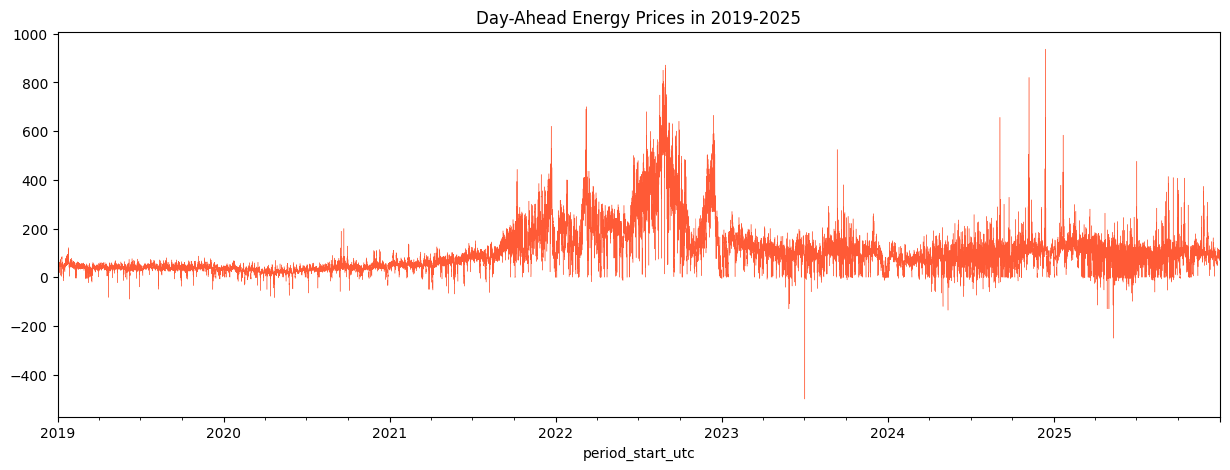

In [7]:
df['price'].plot(figsize=(15, 5), color=NF_ORANGE, linewidth=0.3)
plt.title('Day-Ahead Energy Prices in 2019-2025')

## LSTM (last layer has only 1 output neuron)

In [8]:
# 2. Add residual_load = load - RES 

df["residual_load"] = (
    df["load_forecast_da"]
    - df["off_wind_da"]
    - df["on_wind_da"]
    - df["solar_da"]
)

In [28]:
# LSTM requires normalized inputs.

features = ["price", "load_forecast_da", "off_wind_da", "on_wind_da", "solar_da"]

# Set feature_range to (-1, 1)
scaler = MinMaxScaler(feature_range=(-1, 1))

# Fit and transform
scaled = scaler.fit_transform(df[features])
len(scaled)

61367

In [10]:
# Create sequences (lags) - in this case our lag is 1 week, i.e. 168 hours

def create_sequences(data, lookback=168):
    X, y = [], []
    
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, 0])   # price is first column
    
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, lookback=168)


In [29]:
X.shape

(61199, 168, 5)

In [12]:
# Train / test split

split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_test.shape

(12240, 168, 5)

In [ ]:
# Building the LSTM model

model = Sequential()

model.add(LSTM(64, return_sequences=True,
               input_shape=(X_train.shape[1], X_train.shape[2])))

model.add(Dropout(0.2))

model.add(LSTM(32))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 168, 64)           17920     
                                                                 
 dropout (Dropout)           (None, 168, 64)           0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 30369 (118.63 KB)
Trainable params: 30369 (118.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [14]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/20

689/689 [==============================] - 136s 188ms/step - loss: 0.0029 - val_loss: 9.0288e-04
Epoch 2/20
689/689 [==============================] - 129s 188ms/step - loss: 9.9169e-04 - val_loss: 5.8491e-04
Epoch 3/20
689/689 [==============================] - 218s 316ms/step - loss: 6.6998e-04 - val_loss: 4.5060e-04
Epoch 4/20
689/689 [==============================] - 433s 628ms/step - loss: 5.5990e-04 - val_loss: 3.5077e-04
Epoch 5/20
689/689 [==============================] - 354s 514ms/step - loss: 4.7201e-04 - val_loss: 2.6767e-04
Epoch 6/20
689/689 [==============================] - 346s 502ms/step - loss: 4.4540e-04 - val_loss: 3.0826e-04
Epoch 7/20
689/689 [==============================] - 419s 609ms/step - loss: 4.3604e-04 - val_loss: 3.0842e-04
Epoch 8/20
689/689 [==============================] - 443s 643ms/step - loss: 4.0912e-04 - val_loss: 2.6063e-04
Epoch 9/20
689/689 [==============================] - 475s 688ms/step - loss: 3.8313e-04 - val_loss: 3.0881

In [19]:
# Forecast on test set
pred = model.predict(X_test)


383/383 [==============================] - 19s 50ms/step


In [20]:
# Invert predictions back to original scale

# create empty matrix with same number of features
temp = np.zeros((len(pred), scaled.shape[1]))

# put predicted price into first column (price column)
temp[:,0] = pred.flatten()

# inverse transform
pred_real = scaler.inverse_transform(temp)[:,0]


In [17]:
df.head()

,date,year,month,day,dayofyear,hour,week,dayofweek,price,period_end_utc,...,on_wind_act,solar_da,solar_act,gen_forecast_da,gen_actual,res_sum_da,res_sum_act,imputed,interpolated,residual_load
period_start_utc,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,2019-01-01,2019,1,1,1,0,1,1,10.07,2019-01-01 01:00:00+00:00,...,22315.6300,0.0,0.1350,51084.26,53141.07,25669.0050,25183.9800,0,0,16023.5600
2019-01-01 01:00:00+00:00,2019-01-01,2019,1,1,1,1,1,1,-4.08,2019-01-01 02:00:00+00:00,...,23193.3725,0.0,0.1225,51512.67,52534.02,27384.1025,25653.8950,0,0,13203.1300
2019-01-01 02:00:00+00:00,2019-01-01,2019,1,1,1,2,1,1,-9.91,2019-01-01 03:00:00+00:00,...,24508.7150,0.0,0.1250,52693.45,53217.19,29010.1275,27205.4650,0,0,11298.1225
2019-01-01 03:00:00+00:00,2019-01-01,2019,1,1,1,3,1,1,-7.41,2019-01-01 04:00:00+00:00,...,26373.4375,0.0,0.1300,53666.46,54735.54,30359.5675,28951.3075,0,0,10300.0075
2019-01-01 04:00:00+00:00,2019-01-01,2019,1,1,1,4,1,1,-12.55,2019-01-01 05:00:00+00:00,...,27931.3025,0.0,0.1275,54161.85,55846.36,31409.2100,30308.7475,0,0,9538.5200


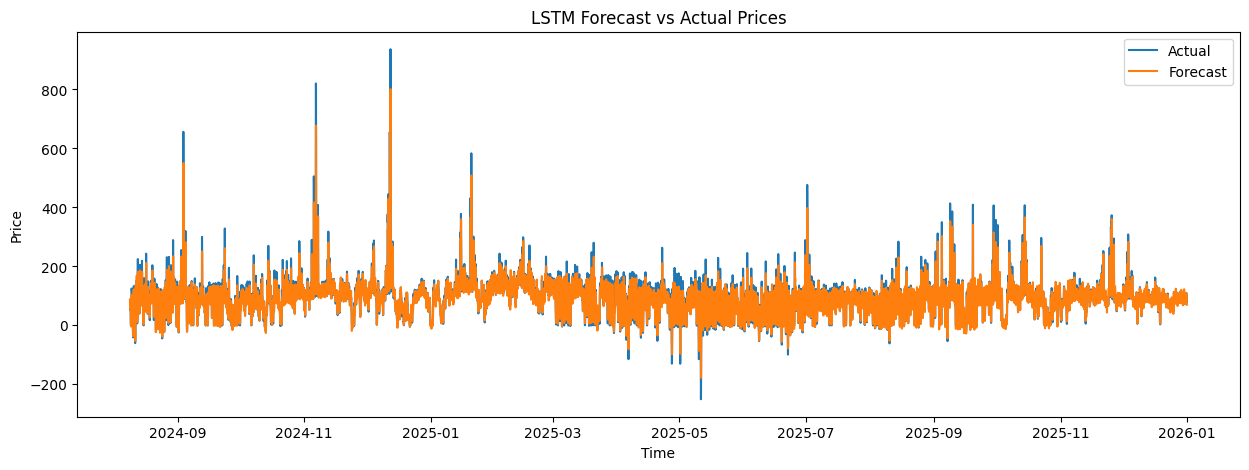

In [21]:
# Plotting the reuslts

lookback = 168

pred_index = df.index[lookback + split:]
actual = df['price'].iloc[lookback + split:]
plt.figure(figsize=(15,5))

plt.plot(pred_index, actual.values, label="Actual")
plt.plot(pred_index, pred_real.flatten(), label="Forecast")

plt.legend()
plt.title("LSTM Forecast vs Actual Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()



In [23]:
# Assessing the models with RMSE, MAPE and MAE

rms_lstm = np.sqrt(mean_squared_error(actual, pred_real))

mape_lstm = mean_absolute_percentage_error(actual, pred_real) * 100

mae_lstm = np.mean(np.abs(actual - pred_real))



# Printing RMSE of all the methods
print("RMSE: ", round(rms_lstm,3))
print("MAPE: ", round(mape_lstm,3))
print("MAE: ", round(mae_lstm,3))

RMSE:  17.657
MAPE:  3.273352460707197e+16
MAE:  9.591


## LSTM (last layer has 24 output neurons and hour of the day and day of the week given as input factors)

In [33]:
df.head()
df.columns

Index(['date', 'year', 'month', 'day', 'dayofyear', 'hour', 'week',
       'dayofweek', 'price', 'period_end_utc', 'c_by_hour', 'load_forecast_da',
       'load_actual', 'off_wind_da', 'off_wind_act', 'on_wind_da',
       'on_wind_act', 'solar_da', 'solar_act', 'gen_forecast_da', 'gen_actual',
       'res_sum_da', 'res_sum_act', 'imputed', 'interpolated',
       'residual_load'],
      dtype='str')

In [42]:
def prepare_features(d_frame):
    
    # Cyclical encoding
    d_frame['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    d_frame['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    d_frame['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    d_frame['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    d_frame['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    d_frame['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Binary features
    d_frame['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    d_frame['is_holiday'] = 0  # You'd populate this from a holiday calendar
    
    # Your original features: load, solar, wind
    # Plus encoded time features
    feature_cols = [
        'price', 'date', 'load_forecast_da', 'off_wind_da', 'on_wind_da',
        'solar_da', 'gen_forecast_da',
        'hour_sin', 'hour_cos',
        'dow_sin', 'dow_cos',
        'month_sin', 'month_cos',
        'is_weekend', 'is_holiday'
    ]
    
    return df[feature_cols]

In [43]:
# Adding German holidays as a feature
import holidays

def add_german_holidays(d_frame):
    """Add German holiday indicator"""
    de_holidays = holidays.Germany(state='BE')  # Berlin, or your state
    d_frame['is_holiday'] = d_frame['date'].dt.date.apply(
        lambda x: 1 if x in de_holidays else 0
    )
    return d_frame

In [44]:
df_lstm = prepare_features(df)
df_lstm = add_german_holidays(df_lstm)
df_lstm.head()

,price,date,load_forecast_da,off_wind_da,on_wind_da,solar_da,gen_forecast_da,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,is_weekend,is_holiday
period_start_utc,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,10.07,2019-01-01,41692.5650,5042.4425,20626.5625,0.0,51084.26,0.000000,1.000000,0.781831,0.62349,0.5,0.866025,0,1
2019-01-01 01:00:00+00:00,-4.08,2019-01-01,40587.2325,5028.4175,22355.6850,0.0,51512.67,0.258819,0.965926,0.781831,0.62349,0.5,0.866025,0,1
2019-01-01 02:00:00+00:00,-9.91,2019-01-01,40308.2500,4977.6500,24032.4775,0.0,52693.45,0.500000,0.866025,0.781831,0.62349,0.5,0.866025,0,1
2019-01-01 03:00:00+00:00,-7.41,2019-01-01,40659.5750,4907.4000,25452.1675,0.0,53666.46,0.707107,0.707107,0.781831,0.62349,0.5,0.866025,0,1
2019-01-01 04:00:00+00:00,-12.55,2019-01-01,40947.7300,4882.8400,26526.3700,0.0,54161.85,0.866025,0.500000,0.781831,0.62349,0.5,0.866025,0,1


In [50]:
# LSTM requires normalized inputs.

price_feature = 'price'
exog_features = ['load_forecast_da', 'off_wind_da', 'on_wind_da',
        'solar_da', 'gen_forecast_da']

# Set feature_range to (-1, 1)
price_scaler = MinMaxScaler(feature_range=(-1, 1))
exog_scaler  = MinMaxScaler(feature_range=(-1, 1))

# Fit and transform
scaled['price'] = price_scaler.fit_transform(df_lstm[[price_feature]])
scaled[exog_features]  = exog_scaler.fit_transform(df_lstm[exog_features])

len(scaled)

61367

In [51]:
# Create sequences (lags) - in this case our lag is 1 week, i.e. 168 hours

lstm_features = ['price'] + exog_features
data_scaled = scaled[lstm_features].values


def create_sequences(data, lookback=168):
    X, y = [], []
    
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, 0])   # price is first column
    
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, lookback=168)

In [54]:
# Train / test split

split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train.shape

(48959, 168, 6)

In [55]:
# Building the LSTM model with 24 output units for 24-hour ahead forecasting

model_24 = Sequential()

model_24.add(LSTM(64, return_sequences=True,
               input_shape=(X_train.shape[1], X_train.shape[2])))

model_24.add(Dropout(0.2))

model_24.add(LSTM(32))

model_24.add(Dense(24))  # 24 output units for 24-hour ahead forecasting

model_24.compile(
    optimizer="adam",
    loss="mse"
)

model_24.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 168, 64)           18176     
                                                                 
 dropout_1 (Dropout)         (None, 168, 64)           0         
                                                                 
 lstm_3 (LSTM)               (None, 32)                12416     
                                                                 
 dense_1 (Dense)             (None, 24)                792       
                                                                 
Total params: 31384 (122.59 KB)
Trainable params: 31384 (122.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [56]:
# Train the model
history = model_24.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/20
689/689 [==============================] - 139s 193ms/step - loss: 0.0040 - val_loss: 0.0011
Epoch 2/20
689/689 [==============================] - 127s 185ms/step - loss: 0.0011 - val_loss: 5.9972e-04
Epoch 3/20
689/689 [==============================] - 138s 201ms/step - loss: 6.2972e-04 - val_loss: 3.8769e-04
Epoch 4/20
689/689 [==============================] - 139s 201ms/step - loss: 4.7825e-04 - val_loss: 3.8855e-04
Epoch 5/20
689/689 [==============================] - 185s 269ms/step - loss: 4.3475e-04 - val_loss: 3.1683e-04
Epoch 6/20
689/689 [==============================] - 151s 220ms/step - loss: 4.0164e-04 - val_loss: 2.4748e-04
Epoch 7/20
689/689 [==============================] - 137s 198ms/step - loss: 3.8359e-04 - val_loss: 2.3563e-04
Epoch 8/20
689/689 [==============================] - 146s 212ms/step - loss: 3.7533e-04 - val_loss: 2.4304e-04
Epoch 9/20
689/689 [==============================] - 136s 198ms/step - loss: 3.6282e-04 - val_loss: 2.3963e-04
Epoc

In [58]:
# Forecast on test set
pred_lstm = model_24.predict(X_test)


383/383 [==============================] - 73s 173ms/step


In [64]:
# 1. Ensure pred_lstm is 2D (samples, horizon)
# 2. Use the scaler directly to handle the (-1, 1) logic automatically
pred_real = price_scaler.inverse_transform(pred_lstm)

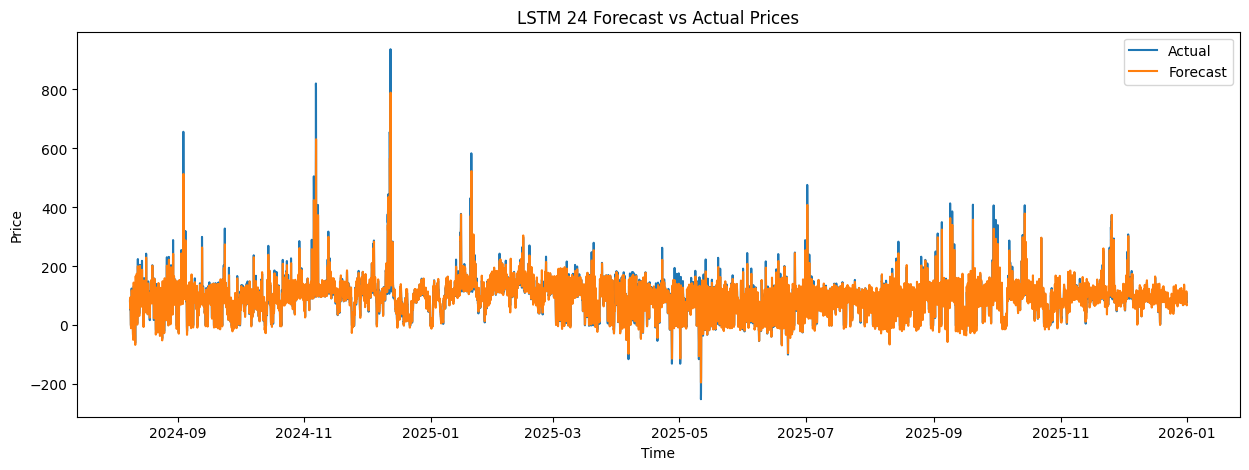

In [65]:
# Plotting the reuslts

lookback = 168

pred_index = df_lstm.index[lookback + split:]
actual = df_lstm['price'].iloc[lookback + split:]
plt.figure(figsize=(15,5))

plt.plot(pred_index, actual.values, label="Actual")
#plt.plot(pred_index, pred_real.flatten(), label="Forecast")

# Take only the first prediction of each 24-hour window
plt.plot(pred_index, pred_real[:, 0], label="Forecast")

plt.legend()
plt.title("LSTM 24 Forecast vs Actual Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [67]:
# Assessing the models with RMSE, MAPE and MAE

rms_lstm_24 = np.sqrt(mean_squared_error(actual, pred_real[:, 0]))

mape_lstm_24 = mean_absolute_percentage_error(actual, pred_real[:, 0]) * 100

mae_lstm_24 = np.mean(np.abs(actual - pred_real[:, 0]))



# Printing RMSE of all the methods
print("RMSE: ", round(rms_lstm_24,3))
print("MAPE: ", round(mape_lstm_24,3))
print("MAE: ", round(mae_lstm_24,3))

RMSE:  17.578
MAPE:  3.797567175283737e+16
MAE:  9.709
